In [1]:
import polars as pl, pymc as pm, arviz as az

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/nettle.csv", separator=";").with_columns(
    language_per_capita=(pl.col("num.lang")/pl.col("k.pop")).log(),
    log_area=(pl.col("area").log()-pl.col("area").log().mean())/pl.col("area").log().std(),
    mean_growing_season=pl.col("mean.growing.season")/pl.col("mean.growing.season").max(),
    sd_growing_season=pl.col("sd.growing.season")/pl.col("sd.growing.season").max(),
)

In [3]:
df

country,num.lang,area,k.pop,num.stations,mean.growing.season,sd.growing.season,language_per_capita,log_area,mean_growing_season,sd_growing_season
str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""Algeria""",18,2381741,25660,102,6.6,2.29,-7.262317,1.373942,0.55,0.390119
"""Angola""",42,1246700,10303,50,6.22,1.87,-5.502521,0.86526,0.518333,0.318569
"""Australia""",234,7713364,17336,134,6.0,4.17,-4.305219,2.29737,0.5,0.710392
"""Bangladesh""",37,143998,118745,20,7.4,0.73,-8.073816,-0.830885,0.616667,0.124361
"""Benin""",52,112622,4889,7,7.14,0.99,-4.543499,-1.024008,0.595,0.168654
…,…,…,…,…,…,…,…,…,…,…
"""Vietnam""",88,331689,68183,40,8.8,1.59,-6.652614,-0.175203,0.733333,0.270869
"""Yemen""",6,527968,12302,2,0.0,0.0,-7.625758,0.190073,0.0,0.0
"""Zaire""",219,2344858,36672,16,9.44,1.9,-5.120697,1.361678,0.786667,0.32368


In [4]:
with pm.Model() as model:
    alpha = pm.Normal("alpha", -5, 2)
    beta_msg = pm.Normal("beta_mgs", 0, 3)
    beta_area_log = pm.Normal("beta_area_log", 0, 1)
    beta_sd_growing_season = pm.Normal("beta_sd_growing_season", 0, 3)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)


    mu = (alpha +
          beta_msg*df["mean_growing_season"].to_numpy() +
          beta_area_log*df["log_area"].to_numpy() +
          beta_sd_growing_season*df["sd_growing_season"].to_numpy() +
          beta_interaction*(df["mean_growing_season"]*df["sd_growing_season"]).to_numpy())
    sigma= pm.Exponential("sigma", 2)

    language_per_cap = pm.StudentT("language_per_cap",nu=3, mu=mu, sigma=sigma, observed=df["language_per_capita"].to_numpy())

    # prior
    prior_predictive = pm.sample_prior_predictive()

    # posterior
    posterior = pm.sample()

    posterior_predictive = pm.sample_posterior_predictive(posterior)

    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta_area_log, beta_interaction, beta_mgs, beta_sd_growing_season, language_per_cap, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_mgs, beta_area_log, beta_sd_growing_season, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [language_per_cap]


Output()

Output()

array([[<Axes: title={'center': 'beta_interaction'}>,
        <Axes: title={'center': 'beta_sd_growing_season'}>,
        <Axes: title={'center': 'beta_area_log'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'beta_mgs'}>]], dtype=object)

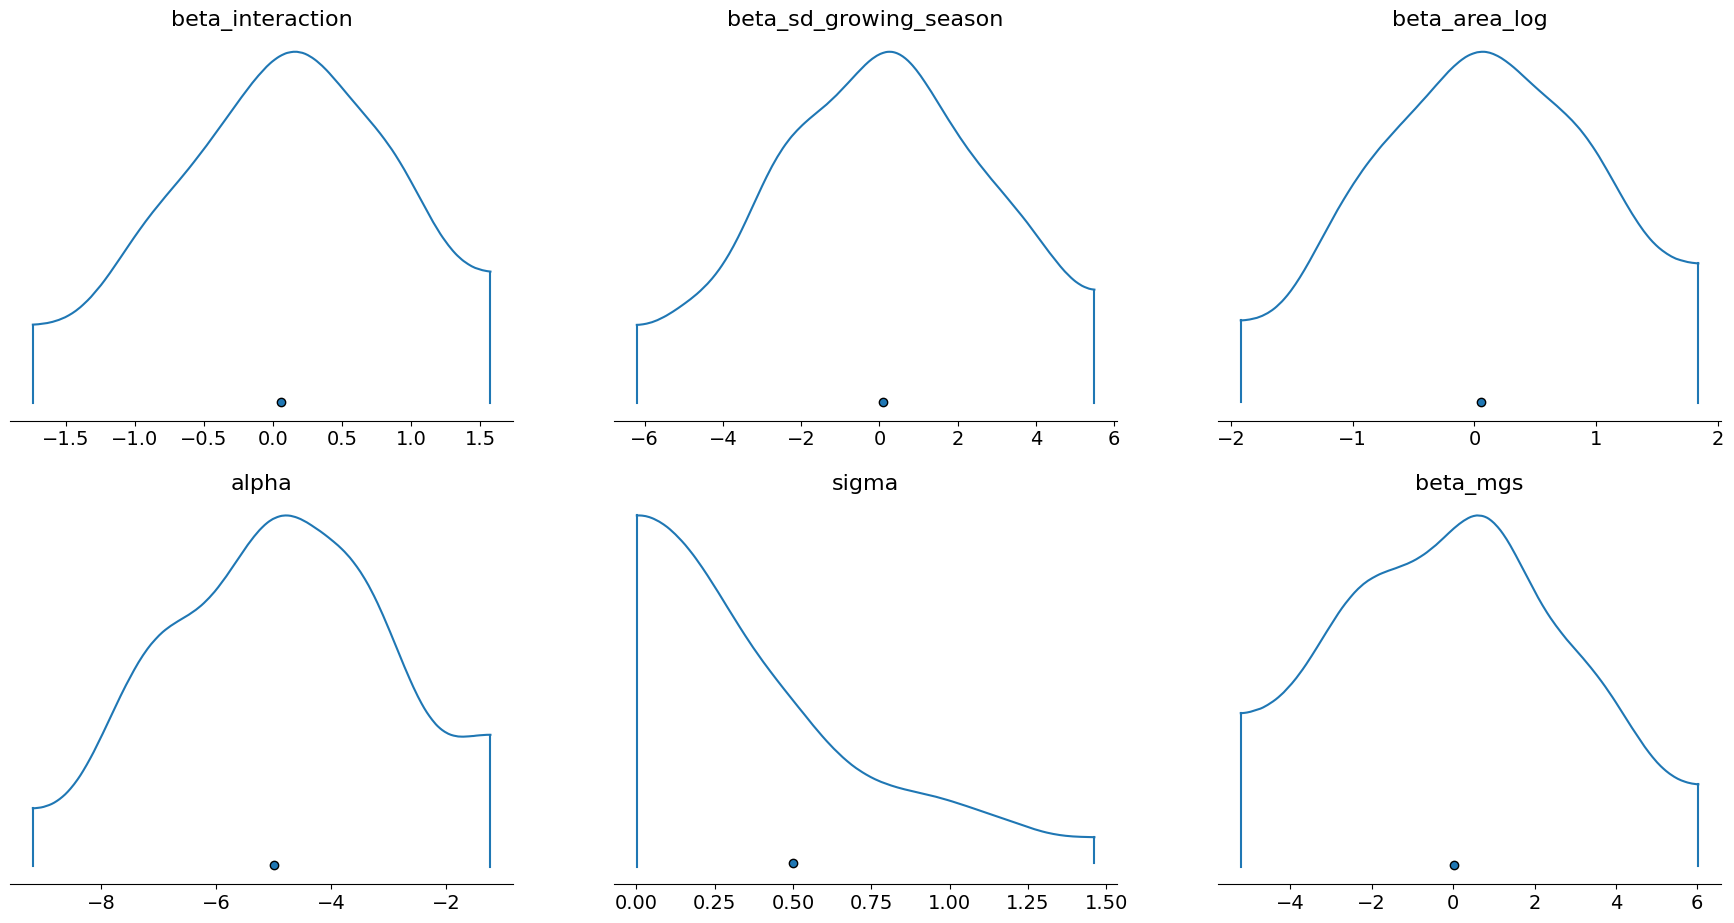

In [5]:
az.plot_density(prior_predictive.prior)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_mgs'}>,
        <Axes: title={'center': 'beta_mgs'}>],
       [<Axes: title={'center': 'beta_area_log'}>,
        <Axes: title={'center': 'beta_area_log'}>],
       [<Axes: title={'center': 'beta_sd_growing_season'}>,
        <Axes: title={'center': 'beta_sd_growing_season'}>],
       [<Axes: title={'center': 'beta_interaction'}>,
        <Axes: title={'center': 'beta_interaction'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

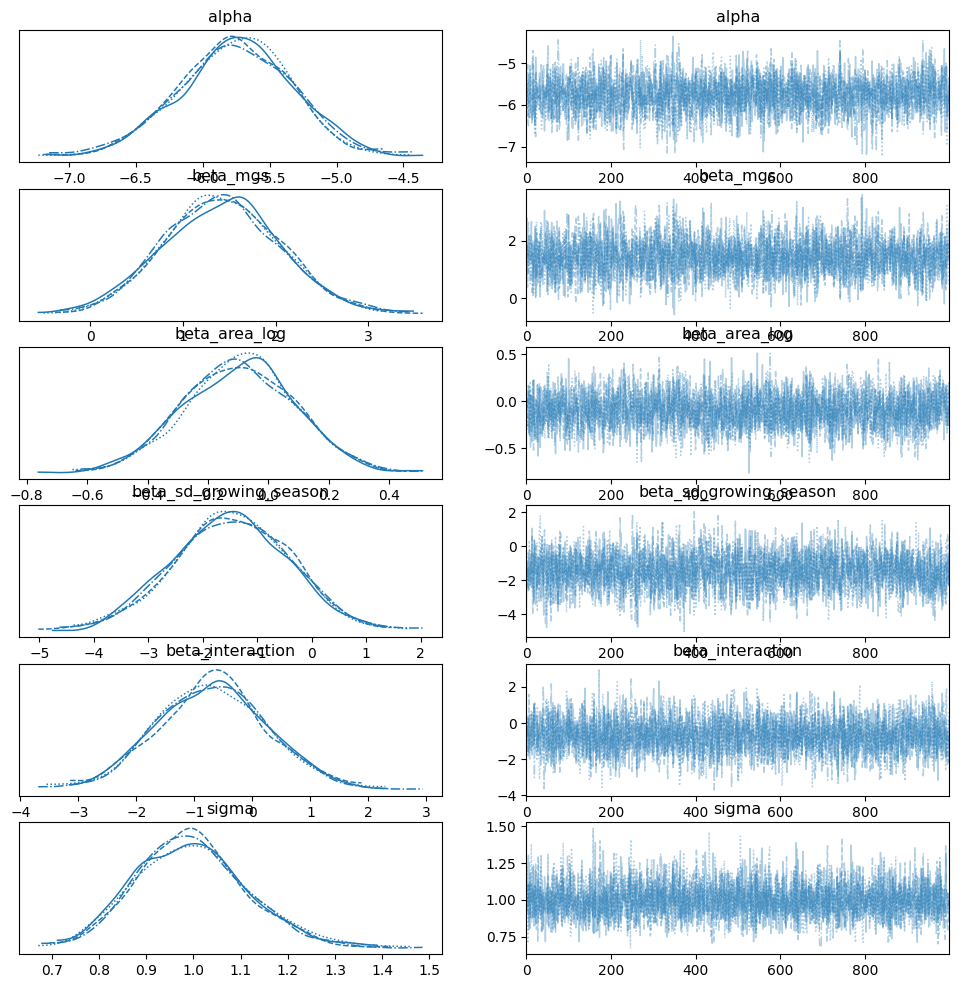

In [6]:
az.plot_trace(posterior)

In [10]:
quantiles = posterior_predictive.posterior_predictive.quantile([0.25, 0.5, 0.75], dim=["chain", "draw"])["language_per_cap"].to_numpy()
df.with_columns(
    waic=az.waic(posterior, pointwise=True).waic_i.to_numpy(),
    posterior_25=quantiles[0, :],
    posterior_50=quantiles[1, :],
    posterior_75=quantiles[2, :],
).select("country", "num.lang", "area", "mean.growing.season", "sd.growing.season", "language_per_capita", "waic", "posterior_25", "posterior_50", "posterior_75")

country,num.lang,area,mean.growing.season,sd.growing.season,language_per_capita,waic,posterior_25,posterior_50,posterior_75
str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""Algeria""",18,2381741,6.6,2.29,-7.262317,-2.114174,-6.622227,-5.831515,-5.074868
"""Angola""",42,1246700,6.22,1.87,-5.502521,-1.047407,-6.440199,-5.694471,-4.931431
"""Australia""",234,7713364,6.0,4.17,-4.305219,-3.109645,-7.329278,-6.515212,-5.69694
"""Bangladesh""",37,143998,7.4,0.73,-8.073816,-3.886077,-5.830038,-5.059591,-4.295927
"""Benin""",52,112622,7.14,0.99,-4.543499,-1.254826,-5.908164,-5.145068,-4.363908
…,…,…,…,…,…,…,…,…,…
"""Vietnam""",88,331689,8.8,1.59,-6.652614,-2.070928,-6.041347,-5.235416,-4.530447
"""Yemen""",6,527968,0.0,0.0,-7.625758,-2.669684,-6.547367,-5.723756,-4.901826
"""Zaire""",219,2344858,9.44,1.9,-5.120697,-1.133447,-6.201356,-5.393819,-4.624545


In [8]:
posterior_predictive.posterior_predictive.quantile([0.25, 0.5, 0.75], dim=["chain", "draw"])["language_per_cap"].to_numpy()

array([[-6.62222687, -6.44019945, -7.32927843, -5.83003776, -5.90816362,
        -6.54594588, -6.50608356, -7.73748994, -6.20177646, -5.98433954,
        -5.60932418, -6.02204334, -6.68953091, -5.81129511, -5.95951178,
        -5.9671157 , -5.94374007, -6.07048102, -6.72581367, -6.73542518,
        -6.70454987, -5.48739663, -5.72550241, -6.03382348, -6.12479694,
        -5.9974745 , -5.57236875, -6.31327643, -6.64525324, -6.06096635,
        -6.90056546, -5.77555063, -5.45809292, -6.79951068, -6.59360704,
        -6.1801496 , -5.30792966, -6.75558382, -6.72090876, -6.72562742,
        -6.30021591, -6.36342799, -6.81760914, -6.29988907, -6.20041543,
        -6.65062862, -6.4382835 , -6.50153279, -5.60858802, -5.99791117,
        -6.17319657, -7.49858827, -5.93777748, -6.85867995, -6.38690101,
        -5.61792547, -4.94986161, -6.69769371, -6.98911626, -6.19931846,
        -7.04948003, -5.03054705, -6.40095081, -6.10214468, -6.04238463,
        -6.55690339, -5.70071838, -4.86771153, -6.5